# Exercise 6 - Decision trees

In this tutorial, we will learn about decision trees. A decision tree is a type of classification algorithm.
Classification algorithms use labeled data to learn patterns that can later be used to predict a categorical target variable.
We will use the Zoo dataset, which originates from the UCI Machine Learning Repository and can be loaded using the following code:

In [38]:
import pandas as pd

import sklearn
sklearn.set_config(display='text')

import matplotlib as mpl

%config InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'bbox_inches': 'tight'}
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['savefig.transparent'] = False

In [39]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"
cols = [
    "animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic",
    "predator", "toothed", "backbone", "breathes", "venomous", "fins", "legs",
    "tail", "domestic", "catsize", "type"
]
zoo = pd.read_csv(url, names=cols)
zoo

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [ ]:
zoo.shape

As we can see above the zoo contains 101 animals (we can see their names in 'animal_name' column) described by 16 boolean* features (like hair, feathers, milk, backbone, etc.), one int column (legs) plus a class label (type of animal: mammal, bird, fish, etc.) we will use the following label_map dictionary to convert the'type' column represent the class label as an integer to more informative column called 'type_name': 

In [41]:
label_map = {1: "1:Mammal", 2: "2:Bird", 3: "3:Reptile" ,4:"4:Fish", 5:"5:Amphibian", 6:"6:Insect", 7:"7:Mollusca"}

In [42]:
zoo['type_name'] = [label_map[c] for c in zoo['type']]

*note that boolean features here are represented as 0 or 1, not as True or False (i.e., as indicator variables and not quite as boolean), and we can use the following code to convert them to real boolean: 

In [ ]:
# zoo_boolean = zoo.copy()
# exclude = ['animal_name', 'type', 'type_name']
# cols_to_convert = [c for c in zoo.columns if c not in exclude]
# zoo_boolean[cols_to_convert] = zoo_boolean[cols_to_convert].astype(bool)
# zoo_boolean

but but despite this, we are going to use them as indicator, for convenience

In [ ]:
# zoo.to_excel(r'C:\Users\hanit\PycharmProjects\machine learning\datasets\zoo.xlsx')

before we dive deep into decision trees, lets explore our data. first lets see how many animles we have from each class:

In [43]:
zoo.groupby('type_name').agg(count=('type', 'count'))

,count
type_name,
1:Mammal,41
2:Bird,20
3:Reptile,5
4:Fish,13
5:Amphibian,4
6:Insect,8
7:Mollusca,10


From The table above, wa can see that the data is imbalanced: most animals in it are mammals (41) and few are amphibian (4).

* One useful property of indicator, or Boolean, variables is that summing their values is equivalent to counting the number of `True` values. For example, summing the `milk` variable gives the number of animals that produce milk.

* Similarly, calculating the mean of an indicator variable gives the proportion of `True` values. For example, calculating the mean of the `milk` variable gives the proportion of animals that produce milk.


In [44]:
zoo.columns

Index(['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'type', 'type_name'],
      dtype='str')

In [45]:
zoo.groupby('type_name').agg(count=('type', 'count'), milk=('milk', 'sum'),  feathers=('feathers', 'sum')).reset_index()


,type_name,count,milk,feathers
0,1:Mammal,41,41,0
1,2:Bird,20,0,20
2,3:Reptile,5,0,0
3,4:Fish,13,0,0
4,5:Amphibian,4,0,0
5,6:Insect,8,0,0
6,7:Mollusca,10,0,0


So, here above we see that out of 41 mammals in the dataframe, 41 has milk. i.e., all mammals. and we can also tell that all other type of animles (birds, reptile, etc..) doesn't have milk (they get 0 count), i.e., milk is a unique feature off mammal. well, a decision tree can use this feature to classify if an observation belong to the mammal class or not. let's see how we create a shallow tree that will use this feature:

* Another useful property of indicator, calculating the mean of an indicator variable gives the proportion of `True` values. For example, calculating the mean of the `milk` variable gives the proportion of animals that produce milk.

In [46]:
zoo['milk'].mean()

np.float64(0.40594059405940597)

## Decision Tree Algorithm

firt we define X as all predictor variables and Y as the label - as expected in classification task. note that we are not going to split data into train and test as expected in classification task yet, since this code focus on demonstration purposes.

In [53]:
X = zoo.iloc[:, 1:-2]  
Y = zoo.iloc[:, -1]

In [54]:
X

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1
97,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0
98,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
99,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [55]:
Y

0        1:Mammal
1        1:Mammal
2          4:Fish
3        1:Mammal
4        1:Mammal
          ...    
96       1:Mammal
97       6:Insect
98       1:Mammal
99     7:Mollusca
100        2:Bird
Name: type_name, Length: 101, dtype: str

now we defined the classifier to be DecisionTreeClassifier, and fit it to our data we called this decision tree classifier (shallow_tree becuse we used max_depth=1, this will be explained in detail later)

In [56]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

shallow_tree = DecisionTreeClassifier(max_depth=1)
shallow_tree.fit(X,Y)

DecisionTreeClassifier(max_depth=1)

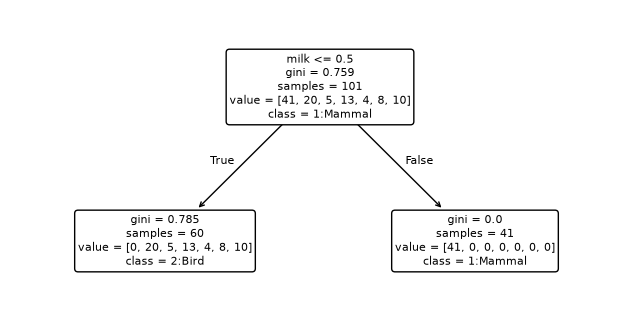

In [58]:
# Plot the tree
plt.figure(figsize=(8,4))
artists = plot_tree(
  shallow_tree,
  feature_names=X.columns,
  class_names=shallow_tree.classes_,
  rounded=True,
  fontsize=8
)

for artist in artists:
  artist.set_color('black')                 # text color
  bbox = artist.get_bbox_patch()
  if bbox is not None:
      bbox.set_facecolor('white')            # node box fill
      bbox.set_edgecolor('black')             # node box border

plt.show()

In the code above, we defined the classifier as a DecisionTreeClassifier and fitted it to our data.

We called this decision tree classifier shallow_tree because we set max_depth=1. We then plotted the fitted tree.
Setting max_depth=1 means that the tree can use only one decision level to split the observations (animals) and predict their class.
In this case, the decision is based on whether the animal has milk. Since milk is an indicator variable that can take only the values 0 or 1, the tree uses the condition milk <= 0.5.
If this condition is true, the observation is sent to the left node. If it is false (milk > 0.5), the observation is sent to the right node.
We can see that the root node (the first node of the tree) contains 101 samples. Of these, 60 samples were sent to the left leaf node and 41 samples were sent to the right leaf node.
A leaf node is a terminal node of the tree, meaning that it does not split into any additional nodes.

Looking at the value vector in the right node, we see:

value = [41, 0, 0, 0, 0, 0, 0]

This means that the node contains 41 samples, and all of them are actually labeled as mammals. The tree also predicts all samples in this node as mammals, as indicated by the last row in the node: class = 1: mammals.

In each leaf node, the tree predicts the class that appears most frequently among the training samples that reach that node.

Looking at the value vector in the left node, we see:

value = [0, 20, 5, 13, 4, 8, 10]

This means that the node contains 60 samples belonging to six different classes. However, the tree classifies all samples that reach this node as birds, because birds are the most common class in this node (bird = 20).

Therefore, in the right node, the tree makes no classification errors on the training samples, since all 41 samples are mammals. This is why the Gini impurity of this node is 0.

In the left node, the samples belong to several different classes, so the node is less pure and its Gini impurity is higher.

Another way to understand the Gini impurity is as a measure of how mixed the classes are within a node. The higher the Gini impurity, the more mixed the node is. A Gini impurity of 0 means that the node is completely pure, meaning that all samples in the node belong to the same class. As we can see, the right node is pure because it contains only mammals.

#### How is Gini impurity calculated?

The Gini impurity is calculated per each node, and it is a function of the number of classes $K$ and the probability $p$ of cases beloning to each class.

$$ \text{Gini impurity} = 1 -\sum_{i=1}^{K} p(class_i)^2$$

So, for the root node: 

$ \text{Gini impurity} = 1 - ((\frac{41}{101})^2 + (\frac{20}{101})^2 + (\frac{5}{101})^2 + (\frac{13}{101})^2 + (\frac{4}{101})^2 + (\frac{8}{101})^2 + (\frac{10}{101})^2) = 0.759$

For the right leaf  node:

$ \text{Gini impurity} = 1 - ((\frac{41}{41})^2 + (\frac{0}{41})^2 + (\frac{0}{41})^2 + (\frac{0}{41})^2 + (\frac{0}{41})^2 + (\frac{0}{41})^2 + (\frac{0}{41})^2) = 0$

For the left leaf  node:

$ \text{Gini impurity} = 1 - ((\frac{0}{60})^2 + (\frac{20}{60})^2 + (\frac{5}{60})^2 + (\frac{13}{60})^2 + (\frac{4}{60})^2 + (\frac{8}{60})^2 + (\frac{10}{60})^2) = 0.785 $

Now that we have calculated the Gini impurity for each leaf, we can calculate the Gini impurity of the split.
The Gini impurity of the split is the weighted average of the leaves' Gini impurities, where each leaf is weighted by the proportion of samples it receives from the parent node.

$ \text{Gini impurity}_{split} = p(\text{left})*\text{Gini impurity}_{left} +  p(\text{right})*\text{Gini impurity}_{right} $

And we can also calculate the Gini gain, which is the difference between the Gini indices of the parent node and the split: 

$ \text{Gini gain} = 0.759 - 0.466 = 0.293$

#### How the tree chooses the splits? 

Now we go further, to generate a deeper tree, i.e., a tree that has more then one split. by using the parameter max_depth=2

In [59]:
two_levels_tree = DecisionTreeClassifier(max_depth=2)
two_levels_tree.fit(X,Y)

DecisionTreeClassifier(max_depth=2)

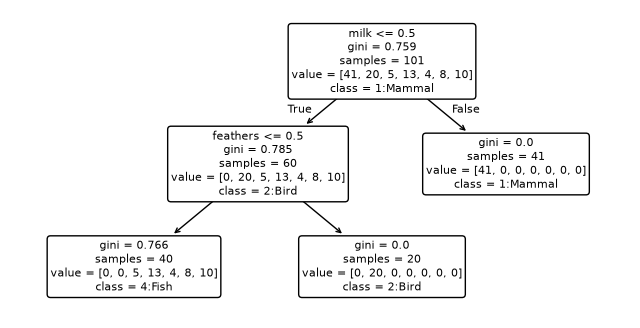

In [62]:
plt.rcdefaults()  # wipe any leftover dark-theme rcParams (patch/axes facecolor etc.)
%config InlineBackend.print_figure_kwargs={'facecolor': 'white'}

fig, ax = plt.subplots(figsize=(8,4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

artists = plot_tree(
  two_levels_tree,
  feature_names=X.columns,
  class_names=shallow_tree.classes_,
  rounded=True,
  fontsize=8,
  ax=ax
)

for artist in artists:
  artist.set_color('black')
  bbox = artist.get_bbox_patch()
  if bbox is not None:
      bbox.set_facecolor('white')
      bbox.set_edgecolor('black')

plt.show()

We can see that the tree chose the feathers feature to generate the next split on the right side.

On the left side of the tree, no further split is generated because the leaf node has reached complete purity (Gini = 0).

But how does the tree choose the best feature (predictor) for a split?

The feature that produces the largest reduction in Gini impurity, also called the Gini gain, is selected to split the current node. This process is repeated at each node as the tree continues to grow.

#### What about continous and multilevel categorical predictors?

When a predictor variable is **Boolean** or **dichotomous** (has only two possible values), it is quite straightforward to use it for a split: observations with one value go to one branch, while observations with the other value go to the other branch.

Decision trees can also split observations using **continuous variables**. In this case, the observations are sorted according to the values of the continuous predictor, and the Gini gain is evaluated at the midpoint between each pair of adjacent values.

If the largest Gini gain among all possible splits and all predictor variables is obtained at one of these midpoints, that midpoint is selected as the split point for the node.

Now that we understand how decision trees choose splits, let's use them in the way classification models are usually built.

First, we need to split the data into a **training set** and a **test set** (and sometimes also a **validation set**). The model is trained on the training set, while the final selected model is evaluated on the test set.

The following code splits our data into **80% training data** and **20% test data**:


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y ,random_state=42)

Now lets train a shallow tree on the training set

In [64]:
shallow_tree = DecisionTreeClassifier(max_depth=1)
shallow_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=1)

Use the shallow_tree to predict Y based on X_test:

In [65]:
y_pred = shallow_tree.predict(X_test)

And evaluate it on the test set, by comparing the predictions with the true labels (y_test):

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 3 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 2 0 0 0 0 0]
 [0 2 0 0 0 0 0]]
              precision    recall  f1-score   support

    1:Mammal       1.00      1.00      1.00         8
      2:Bird       0.31      1.00      0.47         4
   3:Reptile       0.00      0.00      0.00         1
      4:Fish       0.00      0.00      0.00         3
 5:Amphibian       0.00      0.00      0.00         1
    6:Insect       0.00      0.00      0.00         2
  7:Mollusca       0.00      0.00      0.00         2

    accuracy                           0.57        21
   macro avg       0.19      0.29      0.21        21
weighted avg       0.44      0.57      0.47        21



Note that the accuracy of this shallow tree is not very high: 0.57. This is mainly due to the limited depth of the tree.

The performance may improve as we allow the tree to grow and add more splits. However, this usually happens only up to a certain point, after which the tree may start to overfit the training data.

Let's see how the model performs when we use a deeper tree, for example, a tree with a maximum depth of 3:

In [67]:
three_levels_tree = DecisionTreeClassifier(max_depth=3)
three_levels_tree.fit(X_train,y_train)

y_pred = three_levels_tree.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 3 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 2]
 [0 0 0 0 0 0 2]]
              precision    recall  f1-score   support

    1:Mammal       1.00      1.00      1.00         8
      2:Bird       1.00      1.00      1.00         4
   3:Reptile       0.00      0.00      0.00         1
      4:Fish       1.00      1.00      1.00         3
 5:Amphibian       0.00      0.00      0.00         1
    6:Insect       0.00      0.00      0.00         2
  7:Mollusca       0.33      1.00      0.50         2

    accuracy                           0.81        21
   macro avg       0.48      0.57      0.50        21
weighted avg       0.75      0.81      0.76        21



This accuracy of 0.81 is much better.

`max_depth` is a **hyperparameter**, so we can use `GridSearchCV` to find the best value for `max_depth` within a predefined range of possible values (the **hyperparameter search space**).

`GridSearchCV` evaluates each possible value using **cross-validation on the training set**. In cross-validation, the training data is repeatedly divided into smaller training and validation subsets. The model is trained on one part of the data and evaluated on the remaining validation part.

This allows us to compare different hyperparameter values without using the test set.

The **test set is kept aside** during the hyperparameter search and is used only after the best model has been selected. It provides a final evaluation of how well the selected model performs on unseen data.

The following code defines the range of possible values for `max_depth` that we want to search:

In [ ]:
param_grid_max_depth = {
    'max_depth': [2, 4, 6, 8, 10]
}


Next, we define a DecisionTreeClassifier withot using a fixed max_depth (cause we want to search it):

In [ ]:
# Define base model (fixed criterion)
tree = DecisionTreeClassifier(criterion='gini', random_state=42)

Now we use the GridSearchCV, we neet to give it our defined tree as an estimator, the hyperparametr space as an param_grid, the scoring method we want to use to evaluate the preformance (on the validation set as we explained) and sinch GridSearchCV uses Cross validation methos we need to define the number of fold (4 in this case since the dataset is small). 
then we use grid_search fit method to compile every possible model (i.e., with 2, 4, 6, 8 & 10 max depth) end save the best hyperparameter as best_model.

In [68]:
from sklearn.model_selection import GridSearchCV

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid_max_depth,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_


In [69]:
best_model

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

We can see that the best tree is the one have 8 levels. lets see its accuracy scores calculated according to its predict method (the grid_search.best_estimator_ returns the best tree found in the grid search process and its predict method returns its predicted labels when given unseen X (X_test): 

In [ ]:
# Evaluate
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.3f}".format(grid_search.best_score_))
print("Test Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

We got 100% accuracy. 100% accuracy is not very common, but for such dateset holding logical rules which, in any case, determine how nature is divided by humans, it make sense to get such high accuracy. lets also plot this tree:

One way to plot it is the following:

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the tree
plt.figure(figsize=(12,8))
plot_tree(
    best_model, 
    feature_names=X.columns, 
    class_names=best_model.classes_,
    filled=True,     
    rounded=True,      
    fontsize=8
)
plt.show()


note that colors have meaning in this kind of plot: 
* Each class (target label) gets its own base color (e.g. blue, orange, green).
* The intensity (lightness/darkness) of the color shows how pure the node is.

Another way to visualize the decision tree and save it as a PDF file is to use Graphviz.

To make the following code work, you need to:

Install the Python graphviz package using pip install graphviz.
Install the Graphviz application separately from  https://graphviz.org/download/.

The following code plots the decision tree and saves it as a PDF file:

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    best_model,
    out_file=None,
    feature_names=X.columns,
    class_names=Y.astype(str),
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)
graph.render("best_tree")  # saves to iris_tree.pdf
graph.view()               # opens PDF viewer

In most cases, like dataset with much more unexplained variability, it will be harder to find the best max_depth hyperparemter. in addition, there are many other parameters then max_depth that we can adjust.
Let us see which model hyperparameters can be adjusted in decision trees by runing the foloowing:

In [72]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
print(dt.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


* criterion: 'gini', 'entropy', 'log_loss' (default is ”gini”)
* max_depth: Controls tree depth. if a node is alredy at this depth, it will not be split further
* min_samples_split: Minimum samples to split a node. if a node has fewer then the specified number, the node will not be split further.
* min_samples_leaf: Minimum samples per leaf node. if splitting a node would result in leaves containing fewer cases then the specified number then node will not be split.
* min_impurity_decrease: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
* ccp_alpha: complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen. By default, no pruning is performed.
* random_state = set to some int to reapet same results at each run
*
Note that we can also define search ranges for two or more hyperparameters.

`GridSearchCV` evaluates all possible combinations of the hyperparameter values defined in the search space and selects the combination that gives the best cross-validation performance.

For example, here we define a range of values for both `max_depth` and `min_samples_split`:

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Define base model (fixed criterion)
tree = DecisionTreeClassifier(criterion='gini', 
                              class_weight='balanced',
                              random_state=42)

# Define hyperparameter grid (without 'criterion')
param_grid = {
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_


In [75]:
best_model

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [76]:
# Evaluate
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.3f}".format(grid_search.best_score_))
print("Test Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Best Parameters: {'max_depth': 6, 'min_samples_split': 2}
Best CV Accuracy: 0.924
Test Accuracy: 1.000

Confusion Matrix:
 [[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 2]]

Classification Report:
               precision    recall  f1-score   support

    1:Mammal       1.00      1.00      1.00         8
      2:Bird       1.00      1.00      1.00         4
   3:Reptile       1.00      1.00      1.00         1
      4:Fish       1.00      1.00      1.00         3
 5:Amphibian       1.00      1.00      1.00         1
    6:Insect       1.00      1.00      1.00         2
  7:Mollusca       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

